# Tree-Based Models and Ensembles

**Flow:** why a single tree captures non-linear splits but overfits → averaging many trees (random forest) → boosting weak trees sequentially (gradient boosting / HistGradientBoosting) → comparing held-out accuracy → reading feature importances *and their caveats*.

Trees split the feature space into axis-aligned regions and predict a constant in each. They handle non-linearities and interactions automatically and need little preprocessing (no scaling required). A single deep tree overfits; **ensembles** fix this by averaging (bagging/forests) or by sequentially correcting errors (boosting).


## 1. Setup and versions

In [1]:
import sys
import numpy as np
import scipy
import sklearn
import matplotlib
import matplotlib.pyplot as plt

# Colorblind-safe Okabe-Ito categorical palette used throughout this curriculum.
OKABE_ITO = [
    '#0072B2',  # blue
    '#E69F00',  # orange
    '#009E73',  # bluish green
    '#D55E00',  # vermillion
    '#CC79A7',  # reddish purple
    '#56B4E9',  # sky blue
    '#F0E442',  # yellow
    '#000000',  # black
]
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print('Python      :', sys.version.split()[0])
print('numpy       :', np.__version__)
print('scipy       :', scipy.__version__)
print('scikit-learn:', sklearn.__version__)
print('matplotlib  :', matplotlib.__version__)


Python      : 3.9.25
numpy       : 1.26.4
scipy       : 1.13.1
scikit-learn: 1.4.2
matplotlib  : 3.8.4


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
    HistGradientBoostingRegressor)
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score, mean_squared_error

rng = np.random.default_rng(31)


## 2. Deterministic synthetic data with non-linear structure
The target depends non-linearly on a few features (a step, a sinusoid, an interaction) plus several pure-noise features. We split before fitting. This lets us later check whether feature importances point at the truly relevant inputs.

In [3]:
n, p = 800, 8
X = rng.uniform(-3, 3, size=(n, p))
y = (2.0 * np.sin(X[:, 0])              # non-linear in feature 0
     + 1.5 * (X[:, 1] > 0).astype(float)  # step in feature 1
     + 0.8 * X[:, 0] * X[:, 2]          # interaction 0 x 2
     + rng.normal(0, 0.5, size=n))       # features 3..7 are noise
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=0)
print(f'Train: {Xtr.shape}, Test: {Xte.shape}. Relevant features: 0, 1, 2; noise: 3-7.')


Train: (560, 8), Test: (240, 8). Relevant features: 0, 1, 2; noise: 3-7.


## 3. A single tree: flexible but overfits when deep
A shallow tree underfits; a very deep tree fits training noise. We show the train vs. test R^2 gap across depths, then choose depth by cross-validation.

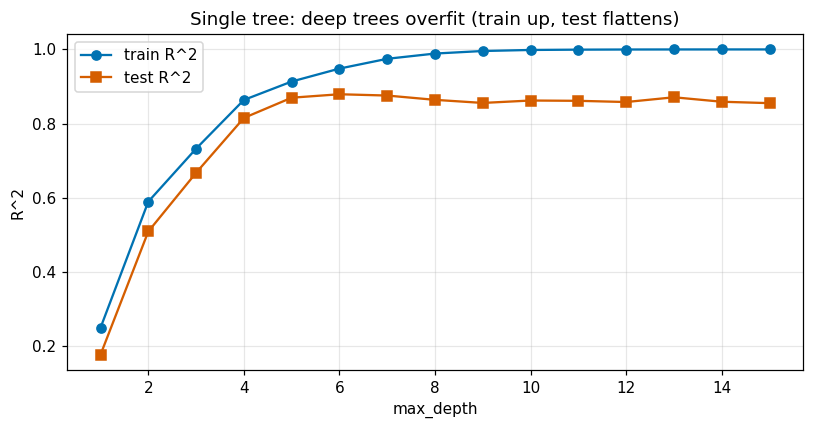

CV-selected max_depth: 7, CV R^2=0.840


In [4]:
depths = range(1, 16)
tr_scores, te_scores = [], []
for d in depths:
    t = DecisionTreeRegressor(max_depth=d, random_state=0).fit(Xtr, ytr)
    tr_scores.append(r2_score(ytr, t.predict(Xtr)))
    te_scores.append(r2_score(yte, t.predict(Xte)))

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(list(depths), tr_scores, marker='o', color=OKABE_ITO[0], label='train R^2')
ax.plot(list(depths), te_scores, marker='s', color=OKABE_ITO[3], label='test R^2')
ax.set_xlabel('max_depth'); ax.set_ylabel('R^2')
ax.set_title('Single tree: deep trees overfit (train up, test flattens)')
ax.legend(); plt.tight_layout(); plt.show()

cv = KFold(n_splits=5, shuffle=True, random_state=1)
tree_search = GridSearchCV(DecisionTreeRegressor(random_state=0),
                           {'max_depth': list(depths)}, cv=cv, scoring='r2').fit(Xtr, ytr)
best_tree = tree_search.best_estimator_
print(f'CV-selected max_depth: {tree_search.best_params_["max_depth"]}, '
      f'CV R^2={tree_search.best_score_:.3f}')


We also draw the top of a shallow tree to make the split structure concrete.

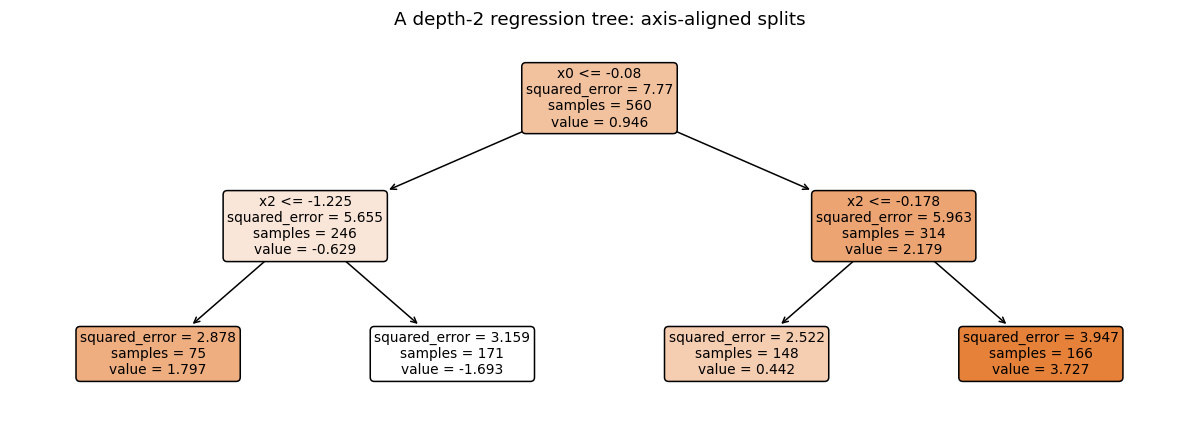

In [5]:
small = DecisionTreeRegressor(max_depth=2, random_state=0).fit(Xtr, ytr)
fig, ax = plt.subplots(figsize=(11, 4))
plot_tree(small, filled=True, feature_names=[f'x{i}' for i in range(p)],
          rounded=True, fontsize=9, ax=ax)
ax.set_title('A depth-2 regression tree: axis-aligned splits')
plt.tight_layout(); plt.show()


## 4. Ensembles: random forest and boosting
- **Random forest** averages many de-correlated deep trees (bagging + random feature subsets), reducing variance.
- **Gradient boosting** fits trees sequentially, each correcting the previous residuals.
- **HistGradientBoosting** is a fast, histogram-based boosting implementation that scales well.

We tune each lightly with CV and compare on the held-out test set against a single tuned tree and an OLS baseline (which cannot capture the interaction/step).

In [6]:
models = {
    'OLS baseline': LinearRegression(),
    'Decision tree (CV depth)': best_tree,
    'Random forest': RandomForestRegressor(n_estimators=300, random_state=0, n_jobs=-1),
    'Gradient boosting': GradientBoostingRegressor(random_state=0),
    'HistGradientBoosting': HistGradientBoostingRegressor(random_state=0),
}
results = {}
for name, mdl in models.items():
    if name not in ('Decision tree (CV depth)',):
        mdl.fit(Xtr, ytr)
    p_te = mdl.predict(Xte)
    results[name] = (r2_score(yte, p_te), mean_squared_error(yte, p_te, squared=False))
    print(f'{name:26s} test R^2={results[name][0]:.3f}  RMSE={results[name][1]:.3f}')


/home/ec2-user/.local/lib/python3.9/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/home/ec2-user/.local/lib/python3.9/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


OLS baseline               test R^2=0.162  RMSE=2.619
Decision tree (CV depth)   test R^2=0.876  RMSE=1.009


/home/ec2-user/.local/lib/python3.9/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Random forest              test R^2=0.925  RMSE=0.785


Gradient boosting          test R^2=0.920  RMSE=0.808
HistGradientBoosting       test R^2=0.934  RMSE=0.734


/home/ec2-user/.local/lib/python3.9/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/home/ec2-user/.local/lib/python3.9/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


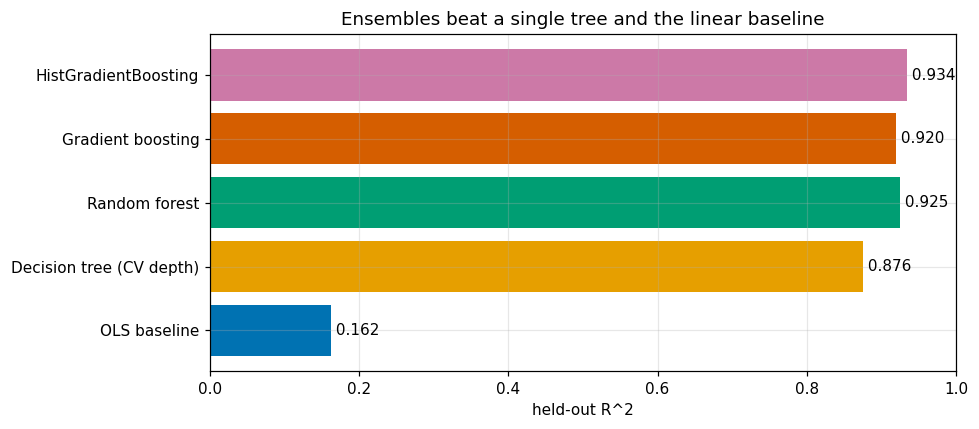

In [7]:
names = list(results)
r2s = [results[n][0] for n in names]
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(names, r2s, color=[OKABE_ITO[i % len(OKABE_ITO)] for i in range(len(names))])
for i, v in enumerate(r2s):
    ax.text(v, i, f' {v:.3f}', va='center')
ax.set_xlabel('held-out R^2'); ax.set_title('Ensembles beat a single tree and the linear baseline')
ax.set_xlim(0, 1); plt.tight_layout(); plt.show()


## 5. Feature importance — and why to distrust the default
Tree **impurity-based** importances (`feature_importances_`) are fast but **biased toward high-cardinality / continuous features** and can be misleading with correlated inputs. **Permutation importance** measured on held-out data is more trustworthy: it shuffles one feature and measures the drop in test score. We compare both on the random forest; the truly relevant features are 0, 1, 2.

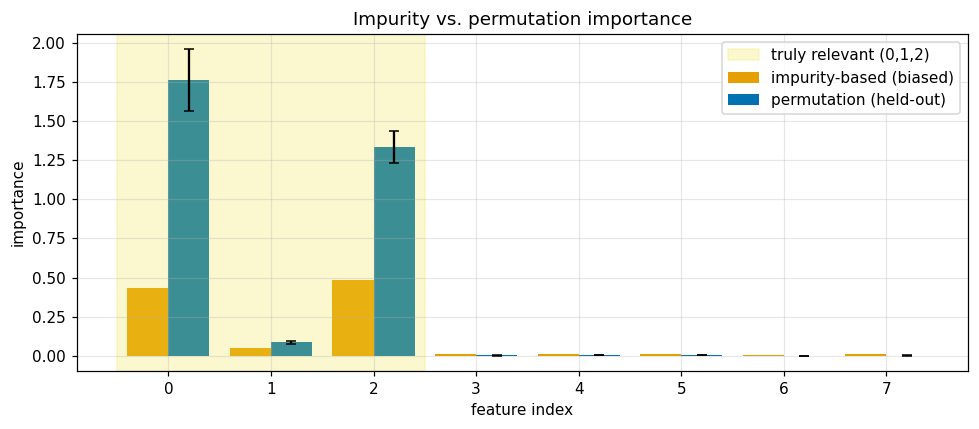

In [8]:
rf = models['Random forest']
impurity = rf.feature_importances_
perm = permutation_importance(rf, Xte, yte, n_repeats=20, random_state=0, n_jobs=-1)

idx = np.arange(p); width = 0.4
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(idx - width/2, impurity, width, color=OKABE_ITO[1], label='impurity-based (biased)')
ax.bar(idx + width/2, perm.importances_mean, width, color=OKABE_ITO[0],
       yerr=perm.importances_std, capsize=3, label='permutation (held-out)')
ax.axvspan(-0.5, 2.5, color=OKABE_ITO[6], alpha=0.25, label='truly relevant (0,1,2)')
ax.set_xlabel('feature index'); ax.set_ylabel('importance')
ax.set_title('Impurity vs. permutation importance')
ax.legend(); plt.tight_layout(); plt.show()


## Key takeaways and caveats

- **A single deep tree overfits.** Control complexity (`max_depth`, `min_samples_leaf`) and pick it with cross-validation.
- **Ensembles win by combining trees:** forests reduce variance by averaging; boosting reduces bias by sequential correction. `HistGradientBoosting` is the fast, scalable default for tabular data.
- **Trees need no feature scaling** and capture non-linearities and interactions automatically — things a plain linear model cannot without engineered features.
- **Do not trust default impurity importances.** They are biased toward continuous/high-cardinality features and mishandle correlated predictors. Prefer **permutation importance on held-out data**, and remember importance is about *this model's* predictions, not causal effect.
- All models were split before fitting, tuned with CV where applicable, and scored once on the held-out test set.
